# 1. Import & Constructor — Ridge Regression

---

## Required Imports

```python
from sklearn.linear_model import Ridge
```

A typical workflow also requires:

```python
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge
```

> **Note:** Ridge is sensitive to the scale of features because the L2 penalty is applied directly to the coefficients. Therefore, **feature scaling (e.g., `StandardScaler`) is strongly recommended**.

---

# Constructor Syntax

```python
Ridge(
    alpha=1.0,
    fit_intercept=True,
    copy_X=True,
    max_iter=None,
    tol=1e-4,
    solver='auto',
    positive=False,
    random_state=None
)
```

---

# Important Parameters

| Parameter       | Default  | Description                                                                           | Common Usage                                                    |
| --------------- | -------- | ------------------------------------------------------------------------------------- | --------------------------------------------------------------- |
| `alpha`         | `1.0`    | Regularization strength. Larger values shrink coefficients more.                      | `0.01`, `0.1`, `1`, `10`, `100`                                 |
| `fit_intercept` | `True`   | Whether to calculate the intercept (bias).                                            | Usually keep `True`                                             |
| `copy_X`        | `True`   | Whether to copy the input data before fitting.                                        | Usually leave as default                                        |
| `max_iter`      | `None`   | Maximum iterations for iterative solvers. Ignored for some solvers.                   | Increase if convergence warnings occur                          |
| `tol`           | `1e-4`   | Tolerance for stopping optimization. Smaller values require more precise convergence. | Leave default unless needed                                     |
| `solver`        | `'auto'` | Algorithm used to solve Ridge Regression.                                             | Usually `'auto'`; choose specific solvers for large/sparse data |
| `positive`      | `False`  | Forces coefficients to be non-negative.                                               | Use only when coefficients must be ≥ 0                          |
| `random_state`  | `None`   | Controls randomness for certain solvers (e.g., `'sag'`, `'saga'`).                    | Set an integer for reproducibility when applicable              |

---

# Parameter Explanation

## 1. `alpha`

```python
Ridge(alpha=1.0)
```

Controls the strength of L2 regularization.

* Small alpha → behaves like Linear Regression.
* Large alpha → stronger coefficient shrinkage.
* `alpha = 0` is mathematically equivalent to Linear Regression, but if you want ordinary least squares, use `LinearRegression` instead.

Example:

```python
Ridge(alpha=0.01)
Ridge(alpha=1)
Ridge(alpha=10)
Ridge(alpha=100)
```

**Rule of thumb:**

* Too small → overfitting may remain.
* Too large → underfitting may occur.

---

## 2. `fit_intercept`

```python
Ridge(fit_intercept=True)
```

Determines whether the model learns an intercept (bias term).

Model equation:

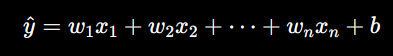

If:

```python
fit_intercept=False
```

the equation becomes

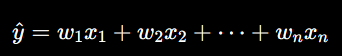

Use `False` **only** if your data has already been centered appropriately.

---

## 3. `copy_X`

```python
Ridge(copy_X=True)
```

* `True` → creates a copy of the training data before fitting.
* `False` → may modify the original array internally, saving memory.

Most users should keep the default.

---

## 4. `max_iter`

```python
Ridge(max_iter=1000)
```

Maximum number of optimization iterations.

Used mainly by iterative solvers such as:

* `'sag'`
* `'saga'`
* `'lbfgs'`

If the model shows a convergence warning, increasing `max_iter` can help.

Example:

```python
Ridge(max_iter=5000)
```

---

## 5. `tol`

```python
Ridge(tol=1e-4)
```

Tolerance for convergence.

Training stops when improvements become smaller than this value.

Smaller value:

```python
tol=1e-6
```

* More accurate convergence
* More iterations
* Longer training time

Larger value:

```python
tol=1e-2
```

* Faster training
* Less precise convergence

---

## 6. `solver`

```python
Ridge(solver='auto')
```

Chooses the optimization algorithm.

### Common solver options

| Solver        | Description                             | When to Use                                                      |
| ------------- | --------------------------------------- | ---------------------------------------------------------------- |
| `'auto'`      | Automatically selects a suitable solver | Recommended for most cases                                       |
| `'svd'`       | Singular Value Decomposition            | Very stable, especially with multicollinearity                   |
| `'cholesky'`  | Cholesky decomposition                  | Fast for small dense datasets                                    |
| `'lsqr'`      | Iterative least-squares solver          | Large datasets                                                   |
| `'sparse_cg'` | Conjugate Gradient                      | Sparse data                                                      |
| `'sag'`       | Stochastic Average Gradient             | Large datasets with many samples; benefits from feature scaling  |
| `'saga'`      | Improved version of SAG                 | Large datasets; supports sparse data                             |
| `'lbfgs'`     | L-BFGS optimizer                        | Required when `positive=True`; good for constrained optimization |

> In practice, `solver='auto'` is appropriate unless you have a specific reason to choose another solver.

---

## 7. `positive`

```python
Ridge(positive=True)
```

Constrains all learned coefficients to be non-negative.

Without constraint:

```
Area      = 15.2
Bedrooms  = -2.1
Age       = -7.8
```

With `positive=True`:

```
Area      = 13.4
Bedrooms  = 0.0 or positive
Age       = 0.0 or positive
```

Use only when negative coefficients are not meaningful in your application (e.g., certain physical or business models).

---

## 8. `random_state`

```python
Ridge(random_state=42)
```

Controls randomness for solvers that use randomization (such as `'sag'` and `'saga'`).

```python
Ridge(
    solver='sag',
    random_state=42
)
```

For deterministic solvers like `'svd'` or `'cholesky'`, this parameter has no effect.

---

# Recommended Settings

For most regression problems:

```python
ridge = Ridge(
    alpha=1.0,
    fit_intercept=True,
    solver='auto'
)
```

If features are highly correlated or you want to tune performance:

```python
ridge = Ridge(
    alpha=10.0,
    solver='auto'
)
```

In practice, choose the best `alpha` using **cross-validation** (e.g., `GridSearchCV` or `RidgeCV`) rather than guessing.

---

# Best Practices

* **Always scale numerical features** before fitting Ridge Regression.
* Start with `alpha=1.0`, then tune it using cross-validation.
* Use `solver='auto'` unless you have a specific optimization need.
* Increase `max_iter` only if you encounter convergence warnings with iterative solvers.
* Keep `fit_intercept=True` unless your features and target have already been centered.
* Use `positive=True` only when non-negative coefficients are required by the problem domain.

---

# 2. Methods & Attributes — Ridge Regression

The `Ridge` class follows the standard **scikit-learn estimator API**, so most of its methods are the same as other supervised learning models.

---

# Methods Table

| Method         | Purpose                                              | Returns         |
| -------------- | ---------------------------------------------------- | --------------- |
| `fit(X, y)`    | Trains the Ridge Regression model                    | `self`          |
| `predict(X)`   | Predicts target values for new data                  | `numpy.ndarray` |
| `score(X, y)`  | Computes the coefficient of determination (R² score) | `float`         |
| `get_params()` | Returns the model's parameters                       | `dict`          |
| `set_params()` | Updates one or more parameters                       | `self`          |

---

# Attributes Table

| Attribute           | Description                                                                                 |
| ------------------- | ------------------------------------------------------------------------------------------- |
| `coef_`             | Learned coefficients (weights) for each feature                                             |
| `intercept_`        | Learned intercept (bias term)                                                               |
| `n_features_in_`    | Number of input features seen during training                                               |
| `feature_names_in_` | Names of input features (available if input is a pandas DataFrame with string column names) |

---

# 1. `fit()`

## Syntax

```python
model.fit(X_train, y_train)
```

## Purpose

Trains the Ridge Regression model by learning the coefficients and intercept that minimize the Ridge loss function.

After calling `fit()`, the model stores the learned parameters internally.

## Returns

```python
self
```

This allows method chaining (though it is not commonly used).

### Example

```python
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
```

---

# 2. `predict()`

## Syntax

```python
model.predict(X_test)
```

## Purpose

Uses the learned coefficients to predict the target values for new data.

Mathematically,

[
\hat{y} = Xw + b
]

where:

* (X) = Input features
* (w) = Learned coefficients
* (b) = Learned intercept

## Returns

```python
numpy.ndarray
```

### Example

```python
predictions = model.predict(X_test)

print(predictions[:5])
```

Example output:

```text
[152.4 178.9 124.3 201.8 143.6]
```

---

# 3. `score()`

## Syntax

```python
model.score(X_test, y_test)
```

## Purpose

Returns the **R² Score (Coefficient of Determination)**.

Internally, it computes:

[
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
]

This is the same value returned by:

```python
from sklearn.metrics import r2_score

r2_score(y_test, predictions)
```

## Returns

```python
float
```

### Example

```python
score = model.score(X_test, y_test)

print(score)
```

Example output:

```text
0.82
```

Interpretation:

* `1.0` → Perfect predictions
* `0.0` → Same as predicting the mean
* `< 0` → Worse than predicting the mean

---

# 4. `get_params()`

## Syntax

```python
model.get_params()
```

## Purpose

Returns all constructor parameters as a dictionary.

Useful for:

* Inspecting model settings
* Hyperparameter tuning
* `GridSearchCV`
* Saving experiment configurations

## Returns

```python
dict
```

### Example

```python
model = Ridge(alpha=10)

params = model.get_params()

print(params)
```

Output (abridged):

```python
{
    'alpha': 10,
    'fit_intercept': True,
    'solver': 'auto',
    ...
}
```

---

# 5. `set_params()`

## Syntax

```python
model.set_params(alpha=5)
```

## Purpose

Updates one or more parameters without creating a new model object.

Useful when experimenting with different hyperparameters programmatically.

## Returns

```python
self
```

### Example

```python
model = Ridge(alpha=1)

model.set_params(alpha=20)

print(model.get_params()["alpha"])
```

Output:

```text
20
```

> **Note:** If you change parameters after training, call `fit()` again so the model is retrained with the new settings.

---

# Commonly Used Attributes

## 1. `coef_`

### Purpose

Stores the learned coefficient (weight) for each feature.

### Type

```python
numpy.ndarray
```

### Example

```python
print(model.coef_)
```

Example output:

```text
[ 24.8  -6.2  13.5   8.9 -15.7]
```

Interpretation:

* Positive value → Feature increases the prediction.
* Negative value → Feature decreases the prediction.
* Larger absolute value → Greater influence on the prediction.

---

## 2. `intercept_`

### Purpose

Stores the learned bias (constant term).

### Type

```python
float
```

### Example

```python
print(model.intercept_)
```

Example output:

```text
152.13
```

Prediction equation becomes:

[
\hat y = w_1x_1+w_2x_2+\cdots+w_nx_n+b
]

where `intercept_` is (b).

---

## 3. `n_features_in_`

### Purpose

Stores the number of input features used during training.

### Type

```python
int
```

### Example

```python
print(model.n_features_in_)
```

Output:

```text
10
```

Useful for validating that new input data has the correct number of features.

---

## 4. `feature_names_in_`

### Purpose

Stores the feature names used during training.

Available **only if**:

* You train using a **pandas DataFrame**.
* The columns have **string names**.

### Type

```python
numpy.ndarray
```

### Example

```python
print(model.feature_names_in_)
```

Output:

```text
['age' 'bmi' 'bp' 's1' 's2' 's3' 's4' 's5' 's6']
```

This is useful for mapping coefficients back to feature names.

---

# Complete Example

```python
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Load dataset
X, y = load_diabetes(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create model
model = Ridge(alpha=1.0)

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# R² Score
print("R²:", model.score(X_test, y_test))

# Coefficients
print("Coefficients:", model.coef_)

# Intercept
print("Intercept:", model.intercept_)

# Number of features
print("Number of Features:", model.n_features_in_)

# Parameters
print("Parameters:", model.get_params())
```

---